In [2]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt 
from shapely.geometry import box
from matplotlib.colors import ListedColormap
import numpy as np
# https://www.iucnredlist.org/resources/spatial-data-download


In [3]:
gdf = gpd.read_file('MAMMALS_TERRESTRIAL_ONLY.zip')
print(gdf.crs)
print(len(gdf))
gdf.head()

EPSG:4326
12703


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
0,18,Abrocoma boliviensis,1,1,1,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,NaN,NaN,...,RODENTIA,ABROCOMIDAE,Abrocoma,CR,false,true,false,0.305150,0.005520,"POLYGON ((-64.46864 -17.88625, -64.45733 -17.8..."
1,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,0.497459,0.009368,"POLYGON ((125.426 2.74894, 125.4247 2.74344, 1..."
2,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,1.224802,0.046804,"POLYGON ((125.9087 -1.97096, 125.9154 -1.97336..."
3,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,1.453910,0.045252,"POLYGON ((125.45 3.74304, 125.4545 3.74164, 12..."
4,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,2.674807,0.096459,"POLYGON ((125.4067 -1.77926, 125.4054 -1.78686..."


<Axes: >

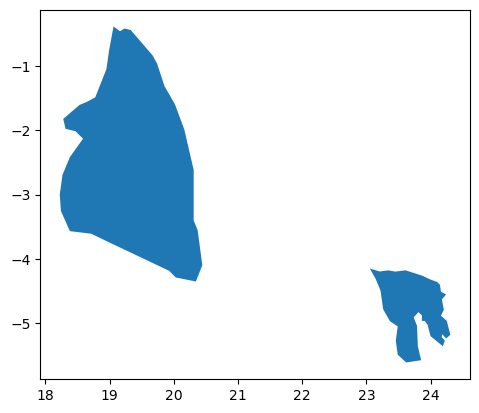

In [4]:
gdf.sample(1).plot()

<Axes: >

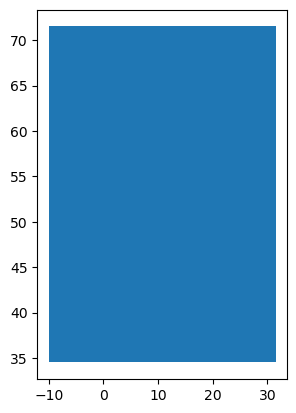

In [5]:
europe_bbox=(-10.0, 34.5, 31.5, 71.5)
minx, miny, maxx, maxy = europe_bbox
bbox_gdf=gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, maxy)], crs='EPSG:4326')
#Turn this into a bounding box geodataframe
bbox_gdf.plot()

In [6]:
#Clip the geodataframe to the bounding box to europe only
gdf_europe=gpd.clip(gdf, bbox_gdf)
print(len(gdf_europe))

598


<Axes: >

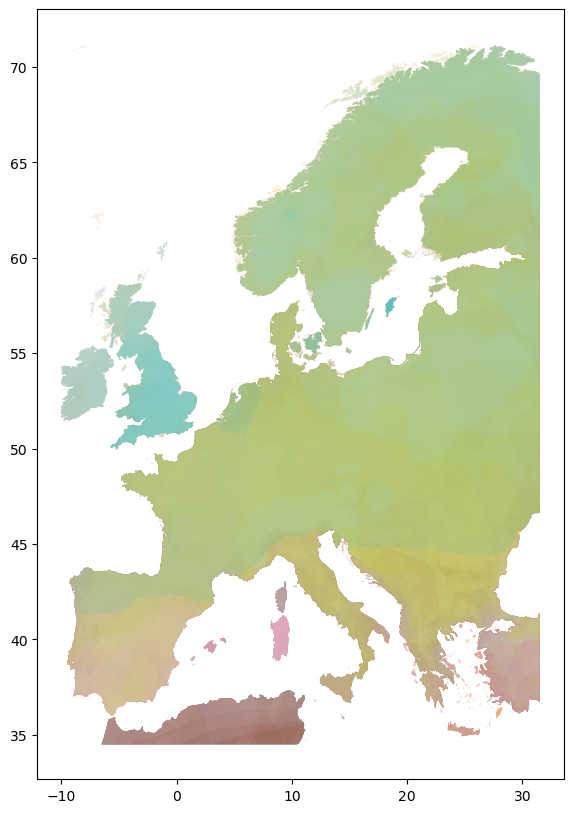

In [7]:
#Visualize the threatened species in europe
f,ax=plt.subplots(figsize=(10,10))
gdf_europe.plot(cmap='tab20', alpha=0.1, linewidth=2, ax=ax)

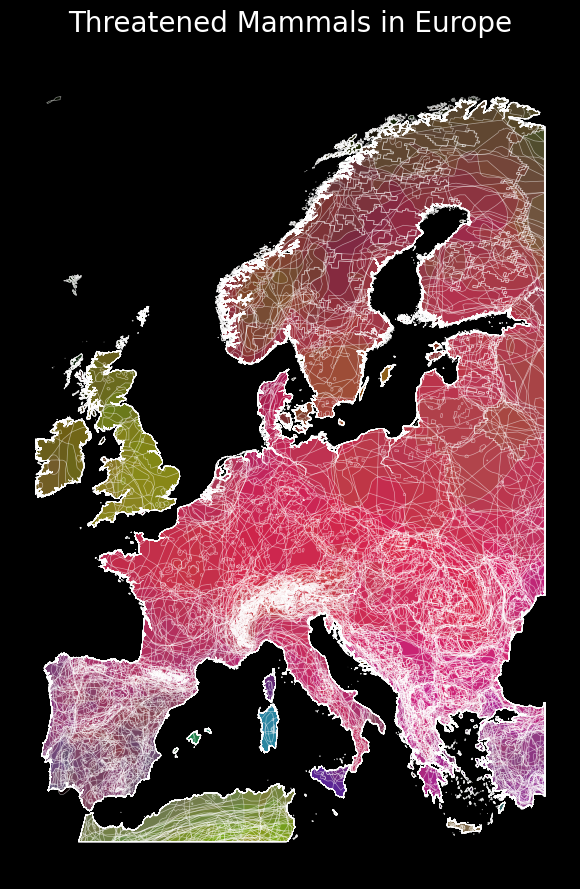

In [8]:
fig, ax = plt.subplots(figsize=(14,9),facecolor='black')

colors=plt.cm.hsv(np.linspace(0,1,256))
neon_cmap=ListedColormap(colors)

gdf_europe.plot(
	ax=ax,
	cmap=neon_cmap,
	alpha=0.05,
	linewidth=0.5
)

gdf_europe.plot(
	ax=ax,
	facecolor='none',
	edgecolor='white',
	alpha=0.5,
	linewidth=0.5
)

ax.set_axis_off()
ax.set_facecolor('black')
title	='Threatened Mammals in Europe'
ax.set_title(title, fontsize=20, color='white', pad=20)
fig.patch.set_facecolor('black')

plt.tight_layout()
plt.show()

In [ ]:
#Interactive map with folium
import folium
import geopandas as gpd
import numpy as np
from matplotlib import cm, colors

m=folium.Map(
	location=[54, 15], 
	zoom_start=4,
	tiles = 'CartoDB dark_matter'
	)

neon_cmap=cm.get_cmap('hsv',256)
norm = colors.Normalize(vmin=0, vmax=len(gdf_europe))

for i,(_,row) in enumerate(gdf_europe.iterrows()):
	color=colors.to_hex(neon_cmap(norm(i)))
	tooltip_text=(
		f"<b>{row['sci_name']}</b><br>"
		f"ID: {row['id_no']}<br>"
		f"Family: {row['family']}<br>"
		f"Order: {row['order_']}<br>"
		f"Category: {row['category']}<br>"
	)
	folium.GeoJson(
		data=row['geometry'].__geo_interface__,
		style_function=lambda feature, color=color: {
			'fill': False,
			'color': color,
			'weight': 0.5,
			'opacity': 0.3
		},
		tooltip=folium.Tooltip(tooltip_text, sticky=True)
	).add_to(m)

# Add title to folium map
title_html = '''
<div style="
    position: fixed;
    top: 20px;
    left: 50%;
    transform: translateX(-50%);
    z-index: 1000;
    background-color: rgba(0, 0, 0, 0.7);
    color: white;
    padding: 10px 24px;
    border-radius: 8px;
    font-size: 18px;
    font-weight: bold;
    font-family: Arial, sans-serif;
    letter-spacing: 1px;
    border: 1px solid rgba(255, 255, 255, 0.2);
    pointer-events: none;
">
    Threatened Mammals in Europe
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

/tmp/ipykernel_6503/3227956074.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  neon_cmap=cm.get_cmap('hsv',256)
